# Results, Tables and Figures

Every numbered table and figure, generated from the
saved pipeline outputs.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import pandas as pd
import numpy as np
from IPython.display import display, Markdown, Image

from src.config import load_config

cfg = load_config()
TABLES = cfg.tables_dir                      # raw result CSVs
PAPER = cfg.tables_dir.parent / 'paper_tables'   # formatted paper tables
FIGS = cfg.figures_dir
PRIMARY = cfg.raw.get('figures', {}).get('primary_market', 'RUSSELL1000')
LABELS = {s['name']: s['label'] for s in cfg.indices}

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', None)

def show_table(name):
    """Render a formatted paper table with its caption."""
    p = PAPER / f'{name}.md'
    if p.exists():
        display(Markdown(p.read_text(encoding='utf-8')))
    else:
        print(f'[missing] {name} - run: python -m src.tables')

def show_figure(name, caption=''):
    p = FIGS / f'{name}.png'
    if p.exists():
        if caption:
            display(Markdown(f'**{caption}**'))
        display(Image(filename=str(p)))
    else:
        print(f'[missing] {name} - run: python -m src.figures')

print('primary market:', LABELS.get(PRIMARY, PRIMARY))
print('paper tables  :', PAPER)
print('figures       :', FIGS)

primary market: Russell 1000
paper tables  : C:\Users\N\Documents\MSc FYP\Regime Portfolio\results\paper_tables
figures       : C:\Users\N\Documents\MSc FYP\Regime Portfolio\results\figures


---
## Section III-A — Dataset

**Table I.** The column to note is `N/T`: the median number of constituents against
the 252-day estimation window. Values above one mean the sample covariance matrix is
singular.

In [2]:
show_table('table1_dataset_summary')

**Dataset summary after calendar alignment. T is trading days; N is the daily constituent count; N/T uses median N against the 252-day estimation window; Missing is the non-membership share of the date-by-constituent panel.**

| Index        |     T |   Unique N |   N min |   N med |   N max |   N/T |   Missing (%) | First      | Last       |
|:-------------|------:|-----------:|--------:|--------:|--------:|------:|--------------:|:-----------|:-----------|
| Russell 1000 | 3,111 |      1,901 |     863 |     995 |   1,042 |  3.95 |          47.6 | 2009-01-05 | 2023-02-28 |
| STOXX 600    | 3,111 |      1,127 |     503 |     600 |     633 |  2.38 |          46.9 | 2009-01-05 | 2023-02-28 |
| STOXX 1800   | 3,021 |      3,292 |      56 |   1,798 |   1,801 |  7.13 |          50.9 | 2009-01-05 | 2023-02-28 |
| Shanghai-A   | 3,111 |      2,095 |     841 |   1,072 |   1,986 |  4.25 |          43.1 | 2009-01-05 | 2023-02-28 |
| TOPIX 1000   | 3,111 |      1,550 |     983 |     998 |   1,002 |  3.96 |          35.7 | 2009-01-05 | 2023-02-28 |


---
## Section III-B — Preprocessing and survivorship

**Table II.** Constituent entries and exits by year for the primary market, with
cross-market totals beneath. Entries are unobservable in the first sample year and
exits in the last, so both are reported as zero there. Non-zero counts throughout the
sample confirm that the investable set is reconstructed point-in-time rather than
taken as the set of survivors known at the end.

In [3]:
show_table('table2_survivorship')
show_table('table2b_survivorship_totals')

**Constituent entries and exits by year, Russell 1000. Entries are unobservable in the first sample year and exits in the last, so both are reported as zero there.**

|   Year |   Active |   Entries |   Exits |   Net |
|-------:|---------:|----------:|--------:|------:|
|   2009 |    1,036 |         0 |      55 |   -55 |
|   2010 |    1,025 |        57 |      47 |    10 |
|   2011 |    1,044 |        69 |      59 |    10 |
|   2012 |    1,042 |        60 |      50 |    10 |
|   2013 |    1,053 |        64 |      48 |    16 |
|   2014 |    1,086 |        74 |      47 |    27 |
|   2015 |    1,118 |        78 |      87 |    -9 |
|   2016 |    1,103 |        73 |      97 |   -24 |
|   2017 |    1,055 |        51 |      71 |   -20 |
|   2018 |    1,048 |        65 |      66 |    -1 |
|   2019 |    1,045 |        60 |      49 |    11 |
|   2020 |    1,072 |        73 |      58 |    15 |
|   2021 |    1,100 |        82 |      78 |     4 |
|   2022 |    1,083 |        53 |      73 |   -20 |
|   2023 |    1,012 |         2 |       0 |     2 |


**Total constituent entries and exits over the sample, by index.**

| Index        |   Total entries |   Total exits |
|:-------------|----------------:|--------------:|
| Russell 1000 |             861 |           885 |
| STOXX 1800   |           3,215 |         1,472 |
| STOXX 600    |             484 |           523 |
| Shanghai-A   |           1,234 |           109 |
| TOPIX 1000   |             510 |           551 |


---
## Section III-C — Stylised facts and cross-market dependence

**Table III.** Every market should show negative skew, substantial excess kurtosis,
rejection of normality, stationarity of returns, and significant ARCH effects.

In [4]:
show_table('table3_stylised_facts')

**Stylised facts of daily index returns. Mean and volatility are annualised. JB is Jarque-Bera; ADF and KPSS are unit-root and stationarity tests; LB(sq) is Ljung-Box on squared returns; ARCH is the ARCH-LM test. Lag orders are given in Section III-C.**

| Index        |   Mean (%) |   Vol (%) |   Skew |   Ex. kurt. |   JB p |   ADF p |   KPSS p |   LB(sq) p |   ARCH p |
|:-------------|-----------:|----------:|-------:|------------:|-------:|--------:|---------:|-----------:|---------:|
| Russell 1000 |       14   |      18.9 |  -0.52 |       10.95 |      0 |       0 |      0.1 |          0 |        0 |
| STOXX 600    |       10.4 |      17.7 |  -0.54 |        8.13 |      0 |       0 |      0.1 |          0 |        0 |
| STOXX 1800   |       12.1 |      15.4 |  -0.77 |       10.91 |      0 |       0 |      0.1 |          0 |        0 |
| Shanghai-A   |        4.3 |      21.3 |  -0.65 |        5.11 |      0 |       0 |      0.1 |          0 |        0 |
| TOPIX 1000   |        9.8 |      19.5 |  -0.29 |        4.17 |      0 |       0 |      0.1 |          0 |        0 |


In [5]:
# Static cross-market correlation, and the Epps-effect check
for f, note in [('dependence_static_pearson.csv', 'Pearson correlation'),
                ('dependence_daily_vs_weekly_epps.csv',
                 'Daily vs weekly correlation (Epps effect)'),
                ('dependence_crisis_vs_calm.csv', 'Crisis vs calm correlation')]:
    p = TABLES / f
    if p.exists():
        display(Markdown(f'**{note}**'))
        display(pd.read_csv(p, index_col=0).round(3))

**Pearson correlation**

,Russell 1000,STOXX 600,STOXX 1800,Shanghai-A,TOPIX 1000
Russell 1000,1.000,0.644,0.868,0.138,0.166
STOXX 600,0.644,1.000,0.761,0.203,0.310
STOXX 1800,0.868,0.761,1.000,0.196,0.344
Shanghai-A,0.138,0.203,0.196,1.000,0.290
TOPIX 1000,0.166,0.310,0.344,0.290,1.000


**Daily vs weekly correlation (Epps effect)**

,daily_corr,weekly_corr,epps_uplift
pair,,,
Russell 1000 ~ STOXX 600,0.644,0.801,0.157
Russell 1000 ~ STOXX 1800,0.868,0.875,0.007
Russell 1000 ~ Shanghai-A,0.138,0.251,0.113
Russell 1000 ~ TOPIX 1000,0.166,0.556,0.390
STOXX 600 ~ STOXX 1800,0.761,0.876,0.115
STOXX 600 ~ Shanghai-A,0.203,0.249,0.046
STOXX 600 ~ TOPIX 1000,0.310,0.619,0.309
STOXX 1800 ~ Shanghai-A,0.196,0.242,0.046
STOXX 1800 ~ TOPIX 1000,0.344,0.650,0.306


**Crisis vs calm correlation**

,n_days,avg_corr,contagion_vs_calm
period,,,
Euro debt crisis,242,0.416,0.043
COVID-19 crash,46,0.608,0.235
ALL CRISIS,288,0.491,0.118
CALM (rest),2823,0.373,0.000


**Fig. 7. Rolling and DCC-GARCH cross-market correlation.**

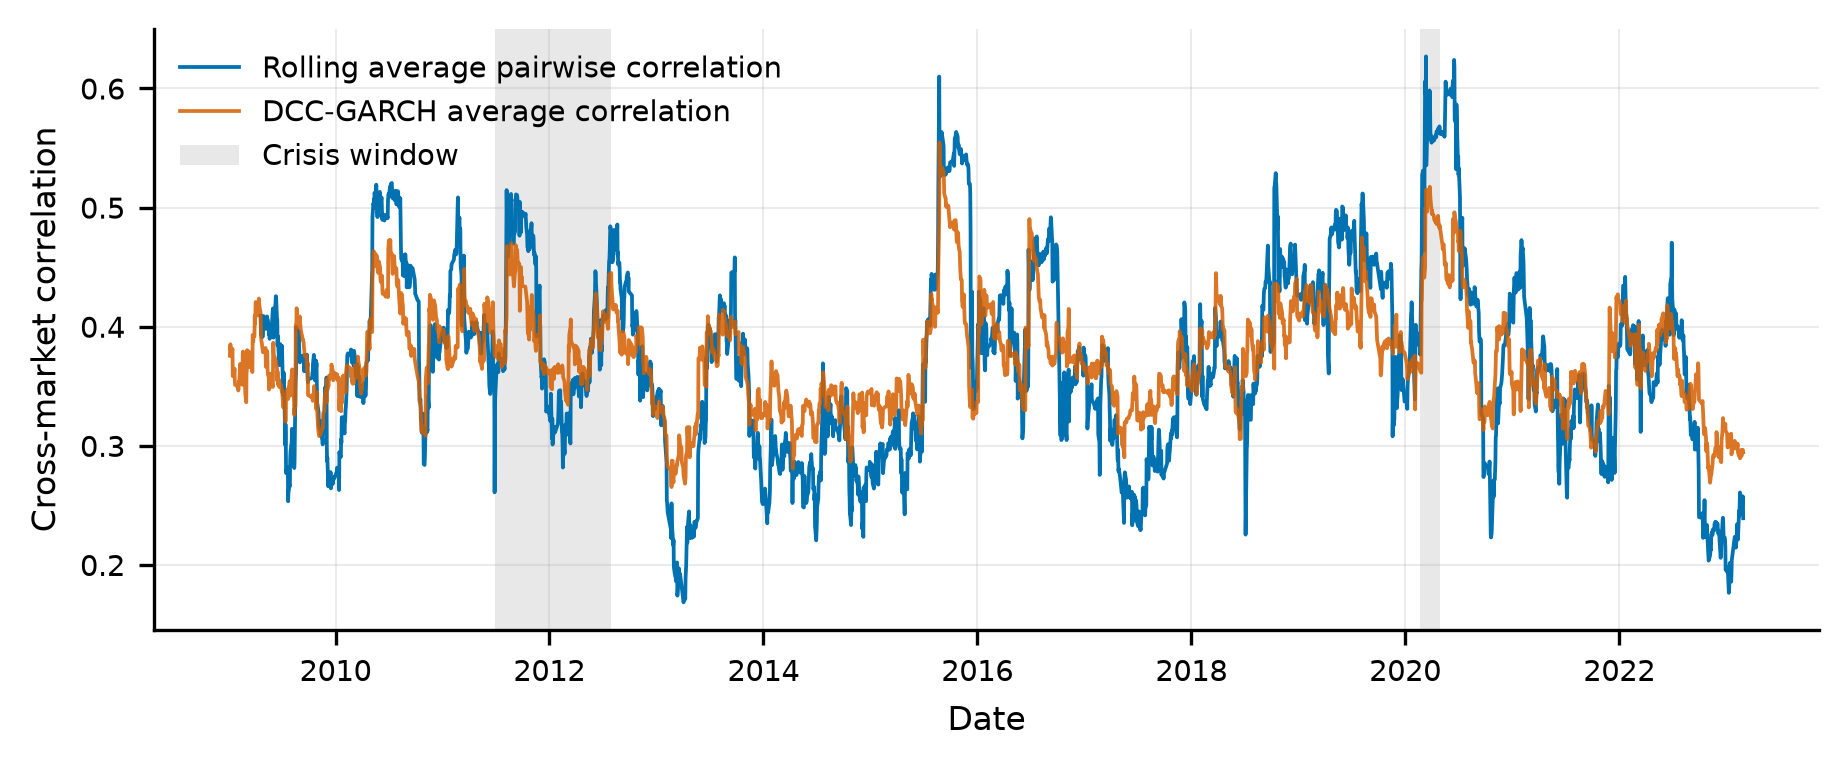

In [6]:
show_figure('fig7_cross_market_correlation',
            'Fig. 7. Rolling and DCC-GARCH cross-market correlation.')

---
## Section III-D — Regime detection

**Table IV and Fig. 1.** Regimes inferred from the
constituent-level cross-section are compared against regimes inferred from the index
return alone. Both models use an identical state grid, selection criterion and seed,
so the only difference is the information set.

In [7]:
show_table('table4_regime_source_comparison')

**Regime detection from constituent-level cross-sectional features versus the index return alone. Turbulent is the share of sample days assigned to the highest-volatility regime; recall is the share of each crisis window assigned to that regime. Both models use an identical state grid, selection criterion and seed.**

| Feature set       |   K |   Days |   Turbulent (%) |   Euro debt crisis recall (%) |   COVID-19 crash recall (%) |
|:------------------|----:|-------:|----------------:|------------------------------:|----------------------------:|
| Constituent-level |   3 |  3,049 |            24.8 |                          60.3 |                        89.1 |
| Index return only |   3 |  3,091 |             3.6 |                          10.7 |                        84.8 |


**Fig. 1. Regimes from constituent-level features vs the index return alone.**

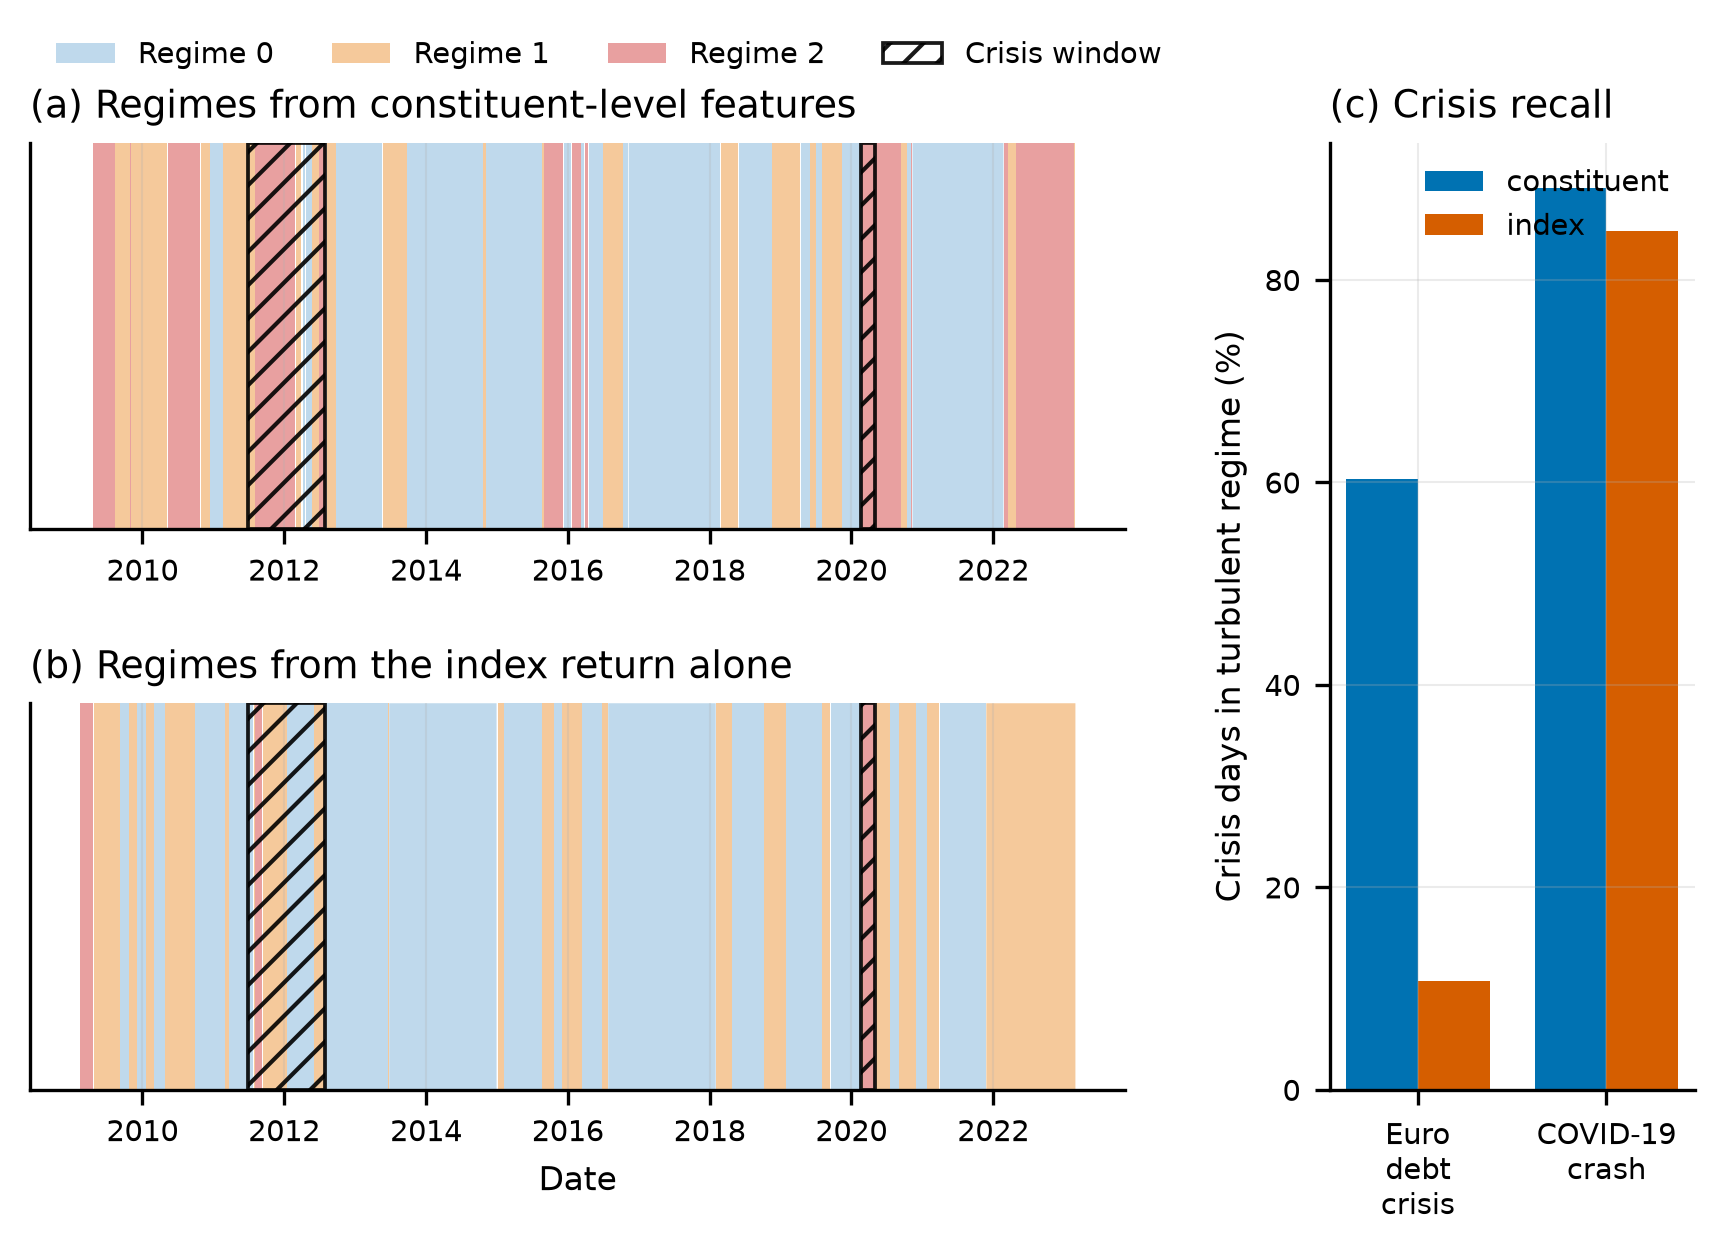

In [8]:
show_figure('fig1_regime_source_comparison',
            'Fig. 1. Regimes from constituent-level features vs the index return alone.')

**Fig. 2. The constituent-level feature series.**

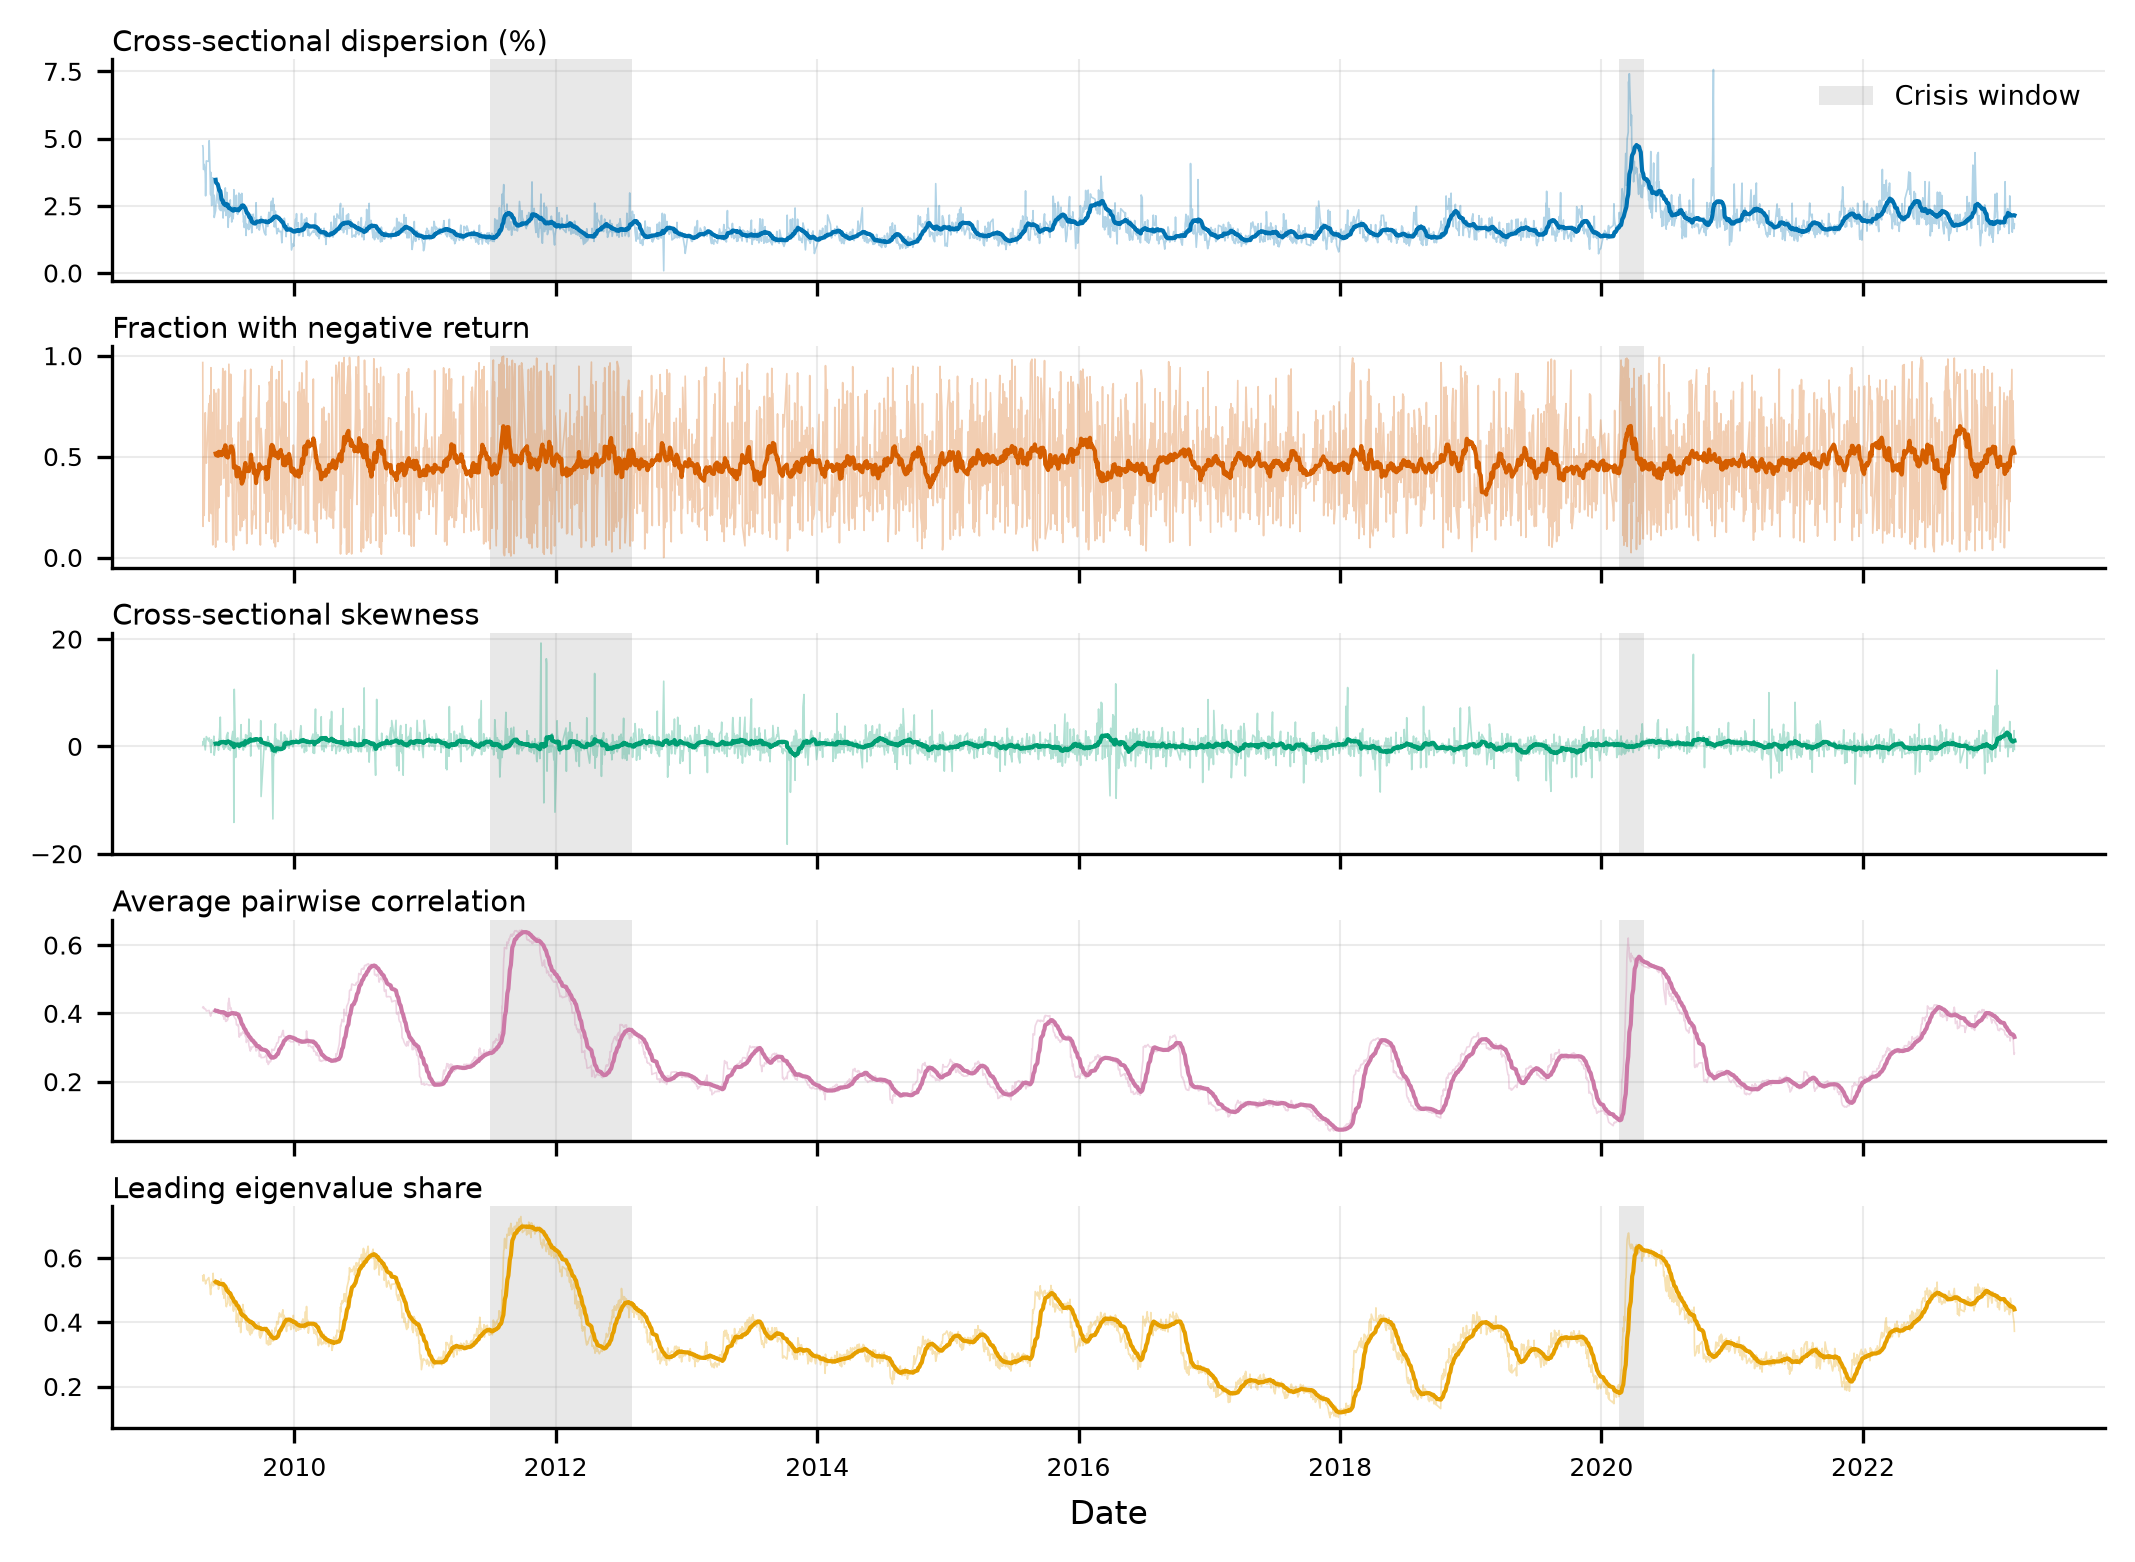

In [9]:
show_figure('fig2_constituent_features',
            'Fig. 2. The constituent-level feature series.')

In [10]:
# Per-regime statistics and the model-order selection grid
for src in ['constituent', 'index']:
    p = TABLES / f'regime_statistics_{PRIMARY}_{src}.csv'
    if p.exists():
        display(Markdown(f'**Per-regime statistics — {src} features**'))
        display(pd.read_csv(p, index_col=0).round(3))

p = TABLES / 'regime_model_selection.csv'
if p.exists():
    display(Markdown('**Model-order selection (the state grid explored)**'))
    display(pd.read_csv(p).round(2))

**Per-regime statistics — constituent features**

,frequency,n_days,mean_ann,vol_ann,avg_duration_days
regime,,,,,
0,0.493,1504,0.105,0.122,83.556
1,0.259,790,0.182,0.150,43.889
2,0.248,755,0.172,0.283,50.333


**Per-regime statistics — index features**

,frequency,n_days,mean_ann,vol_ann,avg_duration_days
regime,,,,,
0,0.621,1920,0.265,0.104,106.667
1,0.343,1060,-0.046,0.224,50.476
2,0.036,111,-0.049,0.558,37.000


**Model-order selection (the state grid explored)**

,index,K,chosen,logL,n_params,AIC,BIC,converged
0,Russell 1000,2,False,2852.11,43,-5618.22,-5359.25,True
1,Russell 1000,3,True,4138.01,68,-8140.03,-7730.49,True
2,STOXX 600,2,False,5164.58,43,-10243.16,-9984.18,True
3,STOXX 600,3,True,6558.23,68,-12980.46,-12570.92,True
4,STOXX 1800,2,False,7515.88,43,-14945.77,-14690.09,True
5,STOXX 1800,3,True,8769.48,68,-17402.97,-16998.65,True
6,Shanghai-A,2,False,6595.53,43,-13105.06,-12846.09,True
7,Shanghai-A,3,True,7859.24,68,-15582.49,-15172.95,True
8,TOPIX 1000,2,False,6452.24,43,-12818.48,-12559.51,True
9,TOPIX 1000,3,True,7729.97,68,-15323.94,-14914.40,True


---
## Results — primary market

**Table V.** Out-of-sample performance for every strategy in the primary market.
`(RC)` denotes the regime-conditional variant of the same method.

In [11]:
show_table('table5_primary_backtest')

**Out-of-sample backtest performance, Russell 1000 (primary market). Returns and volatility are annualised and net of transaction costs. (RC) denotes the regime-conditional variant of the same method. Turnover is mean one-way turnover per rebalance.**

| Strategy    |   Return (%) |   Vol (%) |   Sharpe |   Sortino |   MaxDD (%) |   Calmar | Turnover   |
|:------------|-------------:|----------:|---------:|----------:|------------:|---------:|:-----------|
| 1/N         |         16   |      17.9 |     0.92 |      0.87 |       -31.8 |     0.5  | 0.01       |
| Index       |         15   |      17.4 |     0.89 |      0.83 |       -29.4 |     0.51 | --         |
| MV          |         10.7 |      15.4 |     0.74 |      0.7  |       -23.7 |     0.45 | 0.36       |
| MV (RC)     |          9.5 |      15.9 |     0.65 |      0.61 |       -30.1 |     0.32 | 0.51       |
| MinVar      |         10.2 |      10.9 |     0.95 |      0.88 |       -21.9 |     0.47 | 0.19       |
| MinVar (RC) |         10.1 |      11.2 |     0.92 |      0.84 |       -24.3 |     0.42 | 0.33       |
| HRP         |         15.4 |      14.9 |     1.04 |      0.97 |       -28.5 |     0.54 | 0.12       |
| HRP (RC)    |         14.9 |      14.8 |     1.02 |      0.94 |       -29.3 |     0.51 | 0.15       |
| CVaR        |          6.9 |      11.8 |     0.62 |      0.58 |       -24.6 |     0.28 | 0.34       |
| CVaR (RC)   |          8.1 |      12.1 |     0.7  |      0.64 |       -25.6 |     0.32 | 0.48       |
| Equil.      |         13.4 |      35.5 |     0.53 |      0.52 |       -61.5 |     0.22 | 0.40       |
| Equil. (RC) |         14.7 |      40.1 |     0.54 |      0.56 |       -76.2 |     0.19 | 0.58       |


**Fig. 3. Cumulative wealth.**

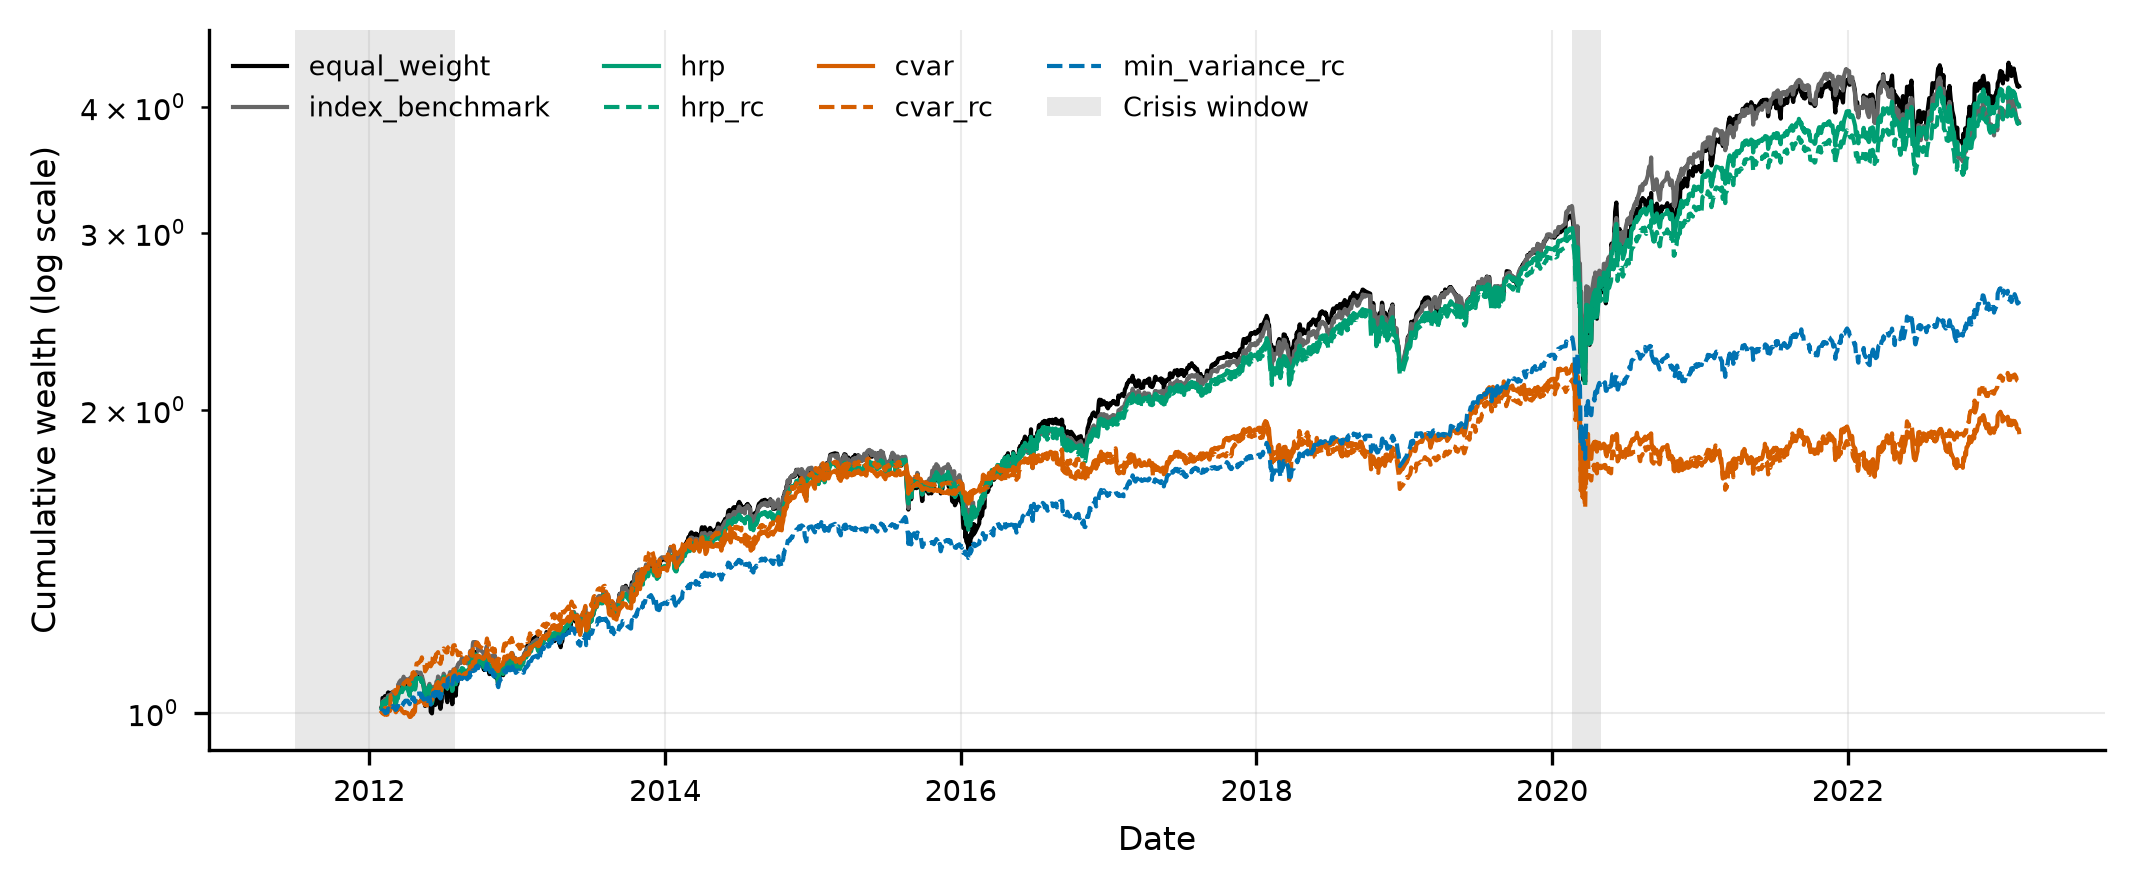

**Fig. 5. Drawdown profiles.**

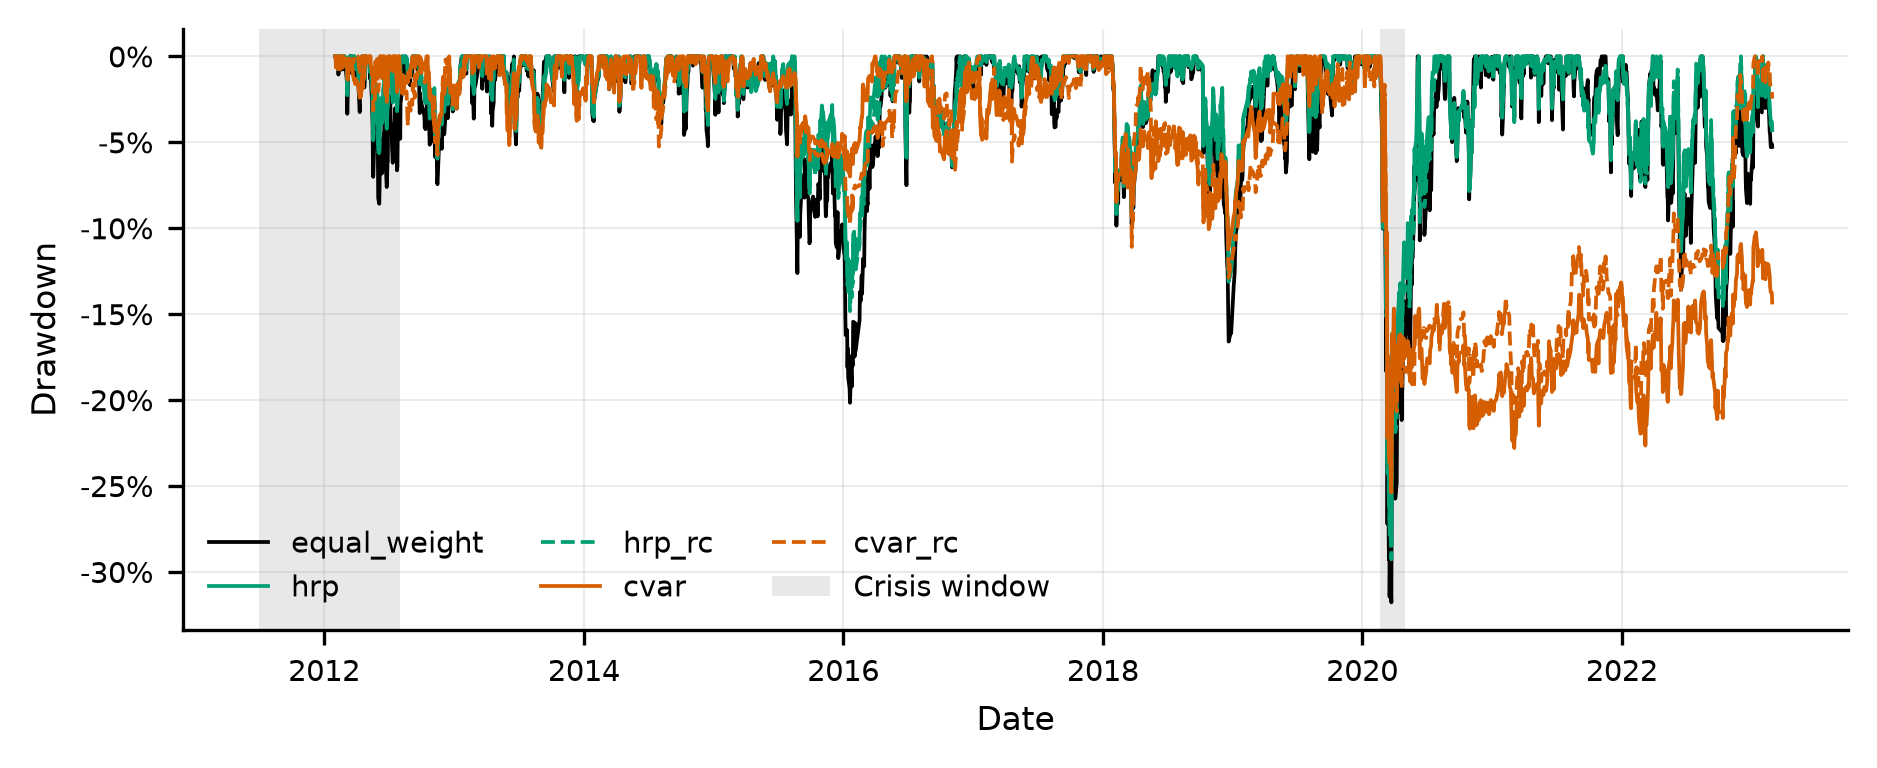

In [12]:
show_figure('fig3_cumulative_wealth', 'Fig. 3. Cumulative wealth.')
show_figure('fig5_drawdown', 'Fig. 5. Drawdown profiles.')

---
## Results — the regime effect

**Table VI and Fig. 4.** The within-method difference
isolates regime conditioning: both members of each pair pass through an identical
walk-forward loop, universe and cost model, differing only in whether the input
moments are regime-weighted.

In [13]:
show_table('table6_regime_effect')

**Within-method regime effect: the change in Sharpe ratio from conditioning a method's inputs on the prevailing regime (regime-conditional minus unconditional). Both members of each pair pass through an identical walk-forward loop, investable universe and cost model, so the difference is attributable to regime conditioning alone.**

| Method           |   Russell 1000 |   STOXX 600 |   STOXX 1800 |   Shanghai-A |   TOPIX 1000 |
|:-----------------|---------------:|------------:|-------------:|-------------:|-------------:|
| Mean-variance    |         -0.085 |       0.227 |       -0.22  |        0.007 |        0.066 |
| Minimum-variance |         -0.03  |       0.274 |       -0.125 |       -0.309 |       -0.047 |
| HRP              |         -0.022 |       0.018 |        0.046 |       -0.104 |       -0.005 |
| CVaR             |          0.082 |       0.186 |       -0.506 |       -0.166 |        0.085 |
| Equilibrium      |          0.011 |       0.243 |       -0.201 |       -0.102 |        0.31  |


**Fig. 4. Within-method regime effect across all five markets.**

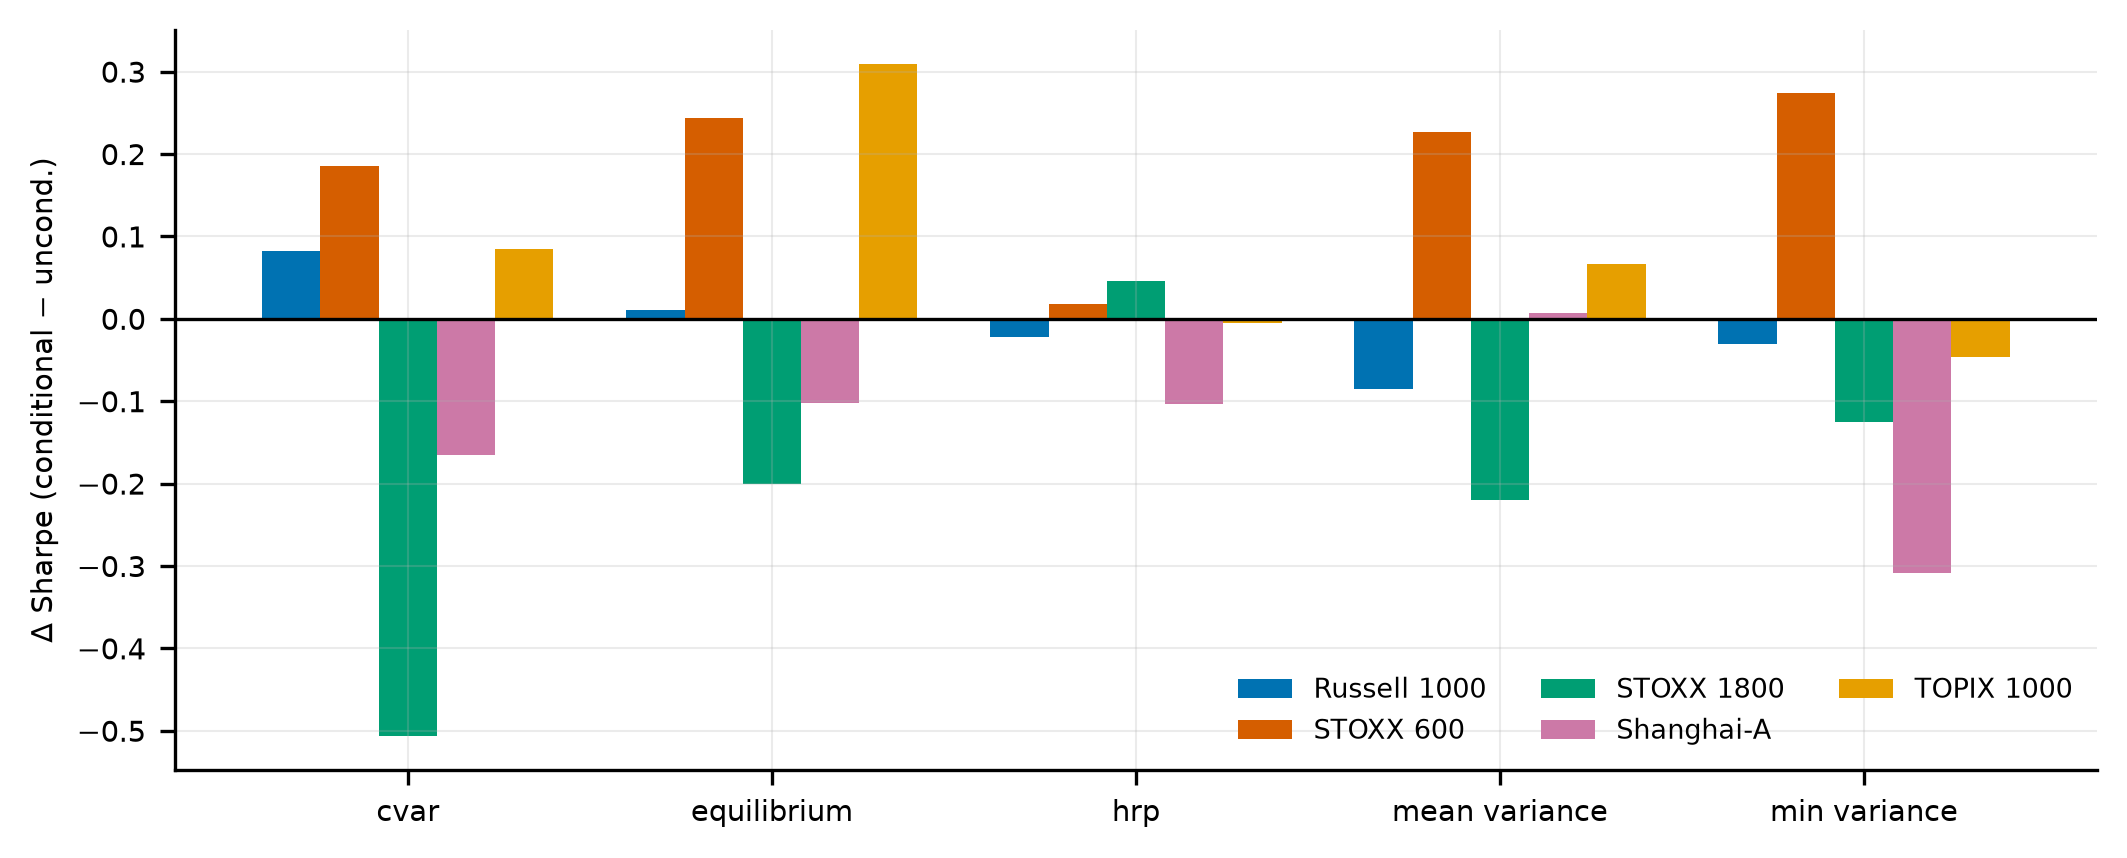

In [14]:
show_figure('fig4_regime_effect',
            'Fig. 4. Within-method regime effect across all five markets.')

---
## Results — statistical inference

**Table VII.** Sharpe-ratio differences against the 1/N benchmark, tested with a
studentised circular block bootstrap, with the false-discovery rate controlled across
the full strategy-by-market grid and a Deflated Sharpe Ratio that discounts for the
number of configurations tried.

In [15]:
show_table('table7_inference')

**Tests of the Sharpe-ratio difference against the 1/N benchmark, Russell 1000. p-values are from a studentised circular block bootstrap with a monthly block length; BH q is the Benjamini-Hochberg adjusted value controlling the false-discovery rate across the full strategy-by-market grid; DSR is the Deflated Sharpe Ratio with 60 configurations tried.**

| Strategy    |   Sharpe |   vs 1/N |   HAC s.e. |     p |   BH q |   DSR |
|:------------|---------:|---------:|-----------:|------:|-------:|------:|
| Index       |     0.89 |   -0.027 |      0.088 | 0.744 |  0.891 | 0.636 |
| MV          |     0.74 |   -0.18  |      0.246 | 0.435 |  0.684 | 0.465 |
| MV (RC)     |     0.65 |   -0.265 |      0.23  | 0.234 |  0.587 | 0.363 |
| MinVar      |     0.95 |    0.03  |      0.209 | 0.882 |  0.971 | 0.697 |
| MinVar (RC) |     0.92 |   -0     |      0.206 | 0.999 |  0.999 | 0.659 |
| HRP         |     1.04 |    0.121 |      0.065 | 0.067 |  0.352 | 0.785 |
| HRP (RC)    |     1.02 |    0.099 |      0.075 | 0.204 |  0.587 | 0.763 |
| CVaR        |     0.62 |   -0.296 |      0.223 | 0.189 |  0.576 | 0.329 |
| CVaR (RC)   |     0.7  |   -0.213 |      0.24  | 0.382 |  0.651 | 0.416 |
| Equil.      |     0.53 |   -0.385 |      0.329 | 0.281 |  0.622 | 0.243 |
| Equil. (RC) |     0.54 |   -0.374 |      0.341 | 0.276 |  0.622 | 0.257 |


In [16]:
# Full grid
p = TABLES / 'inference_sharpe_tests.csv'
if p.exists():
    inf = pd.read_csv(p)
    n_sig = int(inf['bh_reject'].sum())
    print(f'Significant after FDR control: {n_sig} of {len(inf)} tests')
    print(f"Deflated Sharpe Ratio above 0.95: "
          f"{int((inf['dsr'] > 0.95).sum())} of {len(inf)}")
    display(inf.sort_values('p_value')[
        ['market', 'strategy', 'sharpe_diff_ann', 'p_value',
         'bh_qvalue', 'bh_reject', 'dsr']].head(15).round(4))

Significant after FDR control: 0 of 55 tests
Deflated Sharpe Ratio above 0.95: 0 of 55


,market,strategy,sharpe_diff_ann,p_value,bh_qvalue,bh_reject,dsr
32,STOXX 1800,equilibrium_rc,-1.0660,0.0025,0.1100,False,0.0002
43,Shanghai-A,equilibrium_rc,-0.9202,0.0040,0.1100,False,0.0000
42,Shanghai-A,equilibrium,-0.8183,0.0075,0.1375,False,0.0002
28,STOXX 1800,hrp_rc,0.2991,0.0100,0.1375,False,0.6554
25,STOXX 1800,min_variance,0.5853,0.0230,0.2131,False,0.8746
27,STOXX 1800,hrp,0.2530,0.0265,0.2131,False,0.6105
26,STOXX 1800,min_variance_rc,0.4601,0.0300,0.2131,False,0.7957
31,STOXX 1800,equilibrium,-0.8654,0.0310,0.2131,False,0.0018
29,STOXX 1800,cvar,0.5302,0.0555,0.3392,False,0.8590
5,Russell 1000,hrp,0.1215,0.0670,0.3525,False,0.7848


---
## Results — crisis sub-periods

**Table VIII.** Sharpe ratio within each labelled crisis window against the full
sample, computed from the same daily net return series.

In [17]:
show_table('table8_crisis_subperiods')

**Sharpe ratio within labelled crisis windows and over the full sample, Russell 1000. Sub-period Sharpe ratios are computed on the same daily net return series as the full-sample figures.**

| Strategy    |   COVID-19 crash |   Euro debt crisis |   Full sample |
|:------------|-----------------:|-------------------:|--------------:|
| 1/N         |            -1.09 |               0.74 |          0.92 |
| Index       |            -0.93 |               1.5  |          0.89 |
| MV          |            -0.76 |               2.73 |          0.74 |
| MV (RC)     |            -1.07 |               2.46 |          0.65 |
| MinVar      |            -0.73 |               2.58 |          0.95 |
| MinVar (RC) |            -1.06 |               2.26 |          0.92 |
| HRP         |            -0.93 |               1.34 |          1.04 |
| HRP (RC)    |            -1.02 |               1.39 |          1.02 |
| CVaR        |            -1.71 |               2.42 |          0.62 |
| CVaR (RC)   |            -1.84 |               3.39 |          0.7  |
| Equil.      |             0.12 |               2.16 |          0.53 |
| Equil. (RC) |            -1.09 |               1.08 |          0.54 |


---
## Sensitivity analysis

The hyper-parameter space explored, reported so that results can be read in the
context of the design choices that produced them.

**Fig. 6. Sensitivity to the equilibrium view-confidence parameter.**

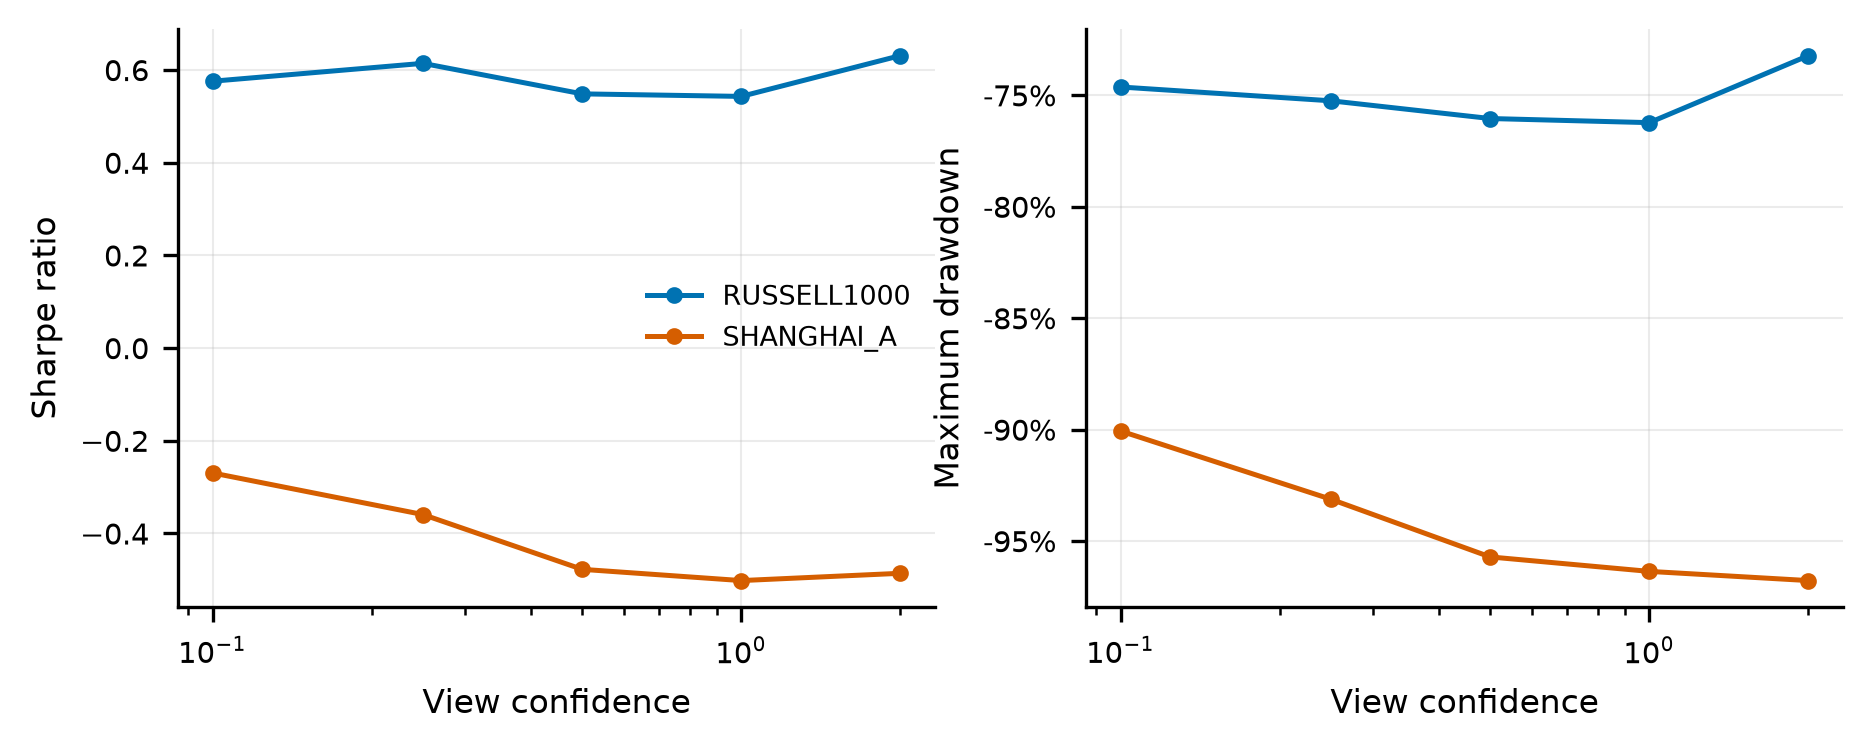

**Hyper-parameter sensitivity. Each row averages across the strategies run at that parameter value, so the table records the space explored rather than a preferred configuration.**

| Parameter       | Index       | Value   |   Mean Sharpe |   Mean MaxDD |
|:----------------|:------------|:--------|--------------:|-------------:|
| View confidence | RUSSELL1000 | 0.1     |          0.58 |        -74.6 |
| View confidence | RUSSELL1000 | 0.25    |          0.61 |        -75.2 |
| View confidence | RUSSELL1000 | 0.5     |          0.55 |        -76   |
| View confidence | RUSSELL1000 | 1.0     |          0.54 |        -76.2 |
| View confidence | RUSSELL1000 | 2.0     |          0.63 |        -73.2 |
| View confidence | SHANGHAI_A  | 0.1     |         -0.27 |        -90.1 |
| View confidence | SHANGHAI_A  | 0.25    |         -0.36 |        -93.1 |
| View confidence | SHANGHAI_A  | 0.5     |         -0.48 |        -95.7 |
| View confidence | SHANGHAI_A  | 1.0     |         -0.5  |        -96.4 |
| View confidence | SHANGHAI_A  | 2.0     |         -0.49 |        -96.8 |
| Lookback (days) | RUSSELL1000 | 63      |          0.75 |        -34.2 |
| Lookback (days) | RUSSELL1000 | 126     |          0.83 |        -30.5 |
| Lookback (days) | RUSSELL1000 | 252     |          0.79 |        -33.9 |
| Lookback (days) | SHANGHAI_A  | 63      |          0    |        -77.8 |
| Lookback (days) | SHANGHAI_A  | 126     |          0.14 |        -74.1 |
| Lookback (days) | SHANGHAI_A  | 252     |          0.13 |        -68.2 |
| Cost (bps)      | RUSSELL1000 | 5.0     |          0.81 |        -33.8 |
| Cost (bps)      | RUSSELL1000 | 10.0    |          0.79 |        -33.9 |
| Cost (bps)      | RUSSELL1000 | 20.0    |          0.77 |        -34   |
| Cost (bps)      | SHANGHAI_A  | 5.0     |          0.14 |        -68   |
| Cost (bps)      | SHANGHAI_A  | 10.0    |          0.13 |        -68.2 |
| Cost (bps)      | SHANGHAI_A  | 20.0    |          0.12 |        -68.6 |
| Rebalance       | RUSSELL1000 | M       |          0.79 |        -33.9 |
| Rebalance       | RUSSELL1000 | Q       |          0.78 |        -32.7 |
| Rebalance       | SHANGHAI_A  | M       |          0.13 |        -68.2 |
| Rebalance       | SHANGHAI_A  | Q       |          0.12 |        -66.6 |


In [18]:
show_figure('fig6_view_confidence',
            'Fig. 6. Sensitivity to the equilibrium view-confidence parameter.')
show_table('tableA2_sensitivity')

---
## Appendix — full strategy grid

**Table A1.** Every strategy in every market.

In [19]:
show_table('tableA1_full_grid')

**Full out-of-sample backtest results for every strategy in every market. Returns and volatility are annualised and net of costs.**

| Index        | Strategy    |   Return (%) |   Vol (%) |   Sharpe |   Sortino |   MaxDD (%) |   Calmar | Turnover   |
|:-------------|:------------|-------------:|----------:|---------:|----------:|------------:|---------:|:-----------|
| Russell 1000 | 1/N         |         16   |      17.9 |     0.92 |      0.87 |       -31.8 |     0.5  | 0.01       |
| Russell 1000 | Index       |         15   |      17.4 |     0.89 |      0.83 |       -29.4 |     0.51 | --         |
| Russell 1000 | MV          |         10.7 |      15.4 |     0.74 |      0.7  |       -23.7 |     0.45 | 0.36       |
| Russell 1000 | MV (RC)     |          9.5 |      15.9 |     0.65 |      0.61 |       -30.1 |     0.32 | 0.51       |
| Russell 1000 | MinVar      |         10.2 |      10.9 |     0.95 |      0.88 |       -21.9 |     0.47 | 0.19       |
| Russell 1000 | MinVar (RC) |         10.1 |      11.2 |     0.92 |      0.84 |       -24.3 |     0.42 | 0.33       |
| Russell 1000 | HRP         |         15.4 |      14.9 |     1.04 |      0.97 |       -28.5 |     0.54 | 0.12       |
| Russell 1000 | HRP (RC)    |         14.9 |      14.8 |     1.02 |      0.94 |       -29.3 |     0.51 | 0.15       |
| Russell 1000 | CVaR        |          6.9 |      11.8 |     0.62 |      0.58 |       -24.6 |     0.28 | 0.34       |
| Russell 1000 | CVaR (RC)   |          8.1 |      12.1 |     0.7  |      0.64 |       -25.6 |     0.32 | 0.48       |
| Russell 1000 | Equil.      |         13.4 |      35.5 |     0.53 |      0.52 |       -61.5 |     0.22 | 0.40       |
| Russell 1000 | Equil. (RC) |         14.7 |      40.1 |     0.54 |      0.56 |       -76.2 |     0.19 | 0.58       |
| STOXX 600    | 1/N         |          9.3 |      16.2 |     0.63 |      0.59 |       -34.7 |     0.27 | 0.01       |
| STOXX 600    | Index       |          9.3 |      16.4 |     0.63 |      0.57 |       -33.7 |     0.28 | --         |
| STOXX 600    | MV          |          8.4 |      14.6 |     0.63 |      0.59 |       -28.6 |     0.29 | 0.37       |
| STOXX 600    | MV (RC)     |         12.3 |      14.8 |     0.86 |      0.79 |       -31.4 |     0.39 | 0.53       |
| STOXX 600    | MinVar      |          6.7 |      10.3 |     0.68 |      0.62 |       -25.1 |     0.27 | 0.19       |
| STOXX 600    | MinVar (RC) |         10.1 |      10.6 |     0.96 |      0.88 |       -27.7 |     0.36 | 0.36       |
| STOXX 600    | HRP         |          9.2 |      13.5 |     0.72 |      0.66 |       -31.4 |     0.29 | 0.12       |
| STOXX 600    | HRP (RC)    |          9.3 |      13.3 |     0.74 |      0.68 |       -30.8 |     0.3  | 0.16       |
| STOXX 600    | CVaR        |          9.2 |      10.9 |     0.86 |      0.81 |       -26.5 |     0.35 | 0.36       |
| STOXX 600    | CVaR (RC)   |         12.4 |      11.9 |     1.05 |      0.99 |       -27.4 |     0.45 | 0.50       |
| STOXX 600    | Equil.      |          0.7 |      33.8 |     0.19 |      0.18 |       -68   |     0.01 | 0.47       |
| STOXX 600    | Equil. (RC) |          9.3 |      32.5 |     0.43 |      0.43 |       -46.5 |     0.2  | 0.68       |
| STOXX 1800   | 1/N         |          8.2 |      13   |     0.67 |      0.62 |       -31.4 |     0.26 | 0.03       |
| STOXX 1800   | Index       |         13.1 |      15.6 |     0.87 |      0.79 |       -29.9 |     0.44 | --         |
| STOXX 1800   | MV          |         10.1 |      12.5 |     0.83 |      0.76 |       -28.8 |     0.35 | 0.34       |
| STOXX 1800   | MV (RC)     |          7   |      12.2 |     0.61 |      0.57 |       -27.8 |     0.25 | 0.51       |
| STOXX 1800   | MinVar      |         10.7 |       8.3 |     1.26 |      1.14 |       -24.6 |     0.43 | 0.20       |
| STOXX 1800   | MinVar (RC) |         10.1 |       8.8 |     1.13 |      1.02 |       -23   |     0.44 | 0.33       |
| STOXX 1800   | HRP         |          9.4 |      10.3 |     0.93 |      0.83 |       -28.3 |     0.33 | 0.15       |
| STOXX 1800   | HRP (RC)    |         10   |      10.3 |     0.97 |      0.86 |       -28.8 |     0.35 | 0.19       |
| STOXX 1800   | CVaR        |         11.3 |       9.2 |     1.2  |      1.13 |       -20.5 |     0.55 | 0.35       |
| STOXX 1800   | CVaR (RC)   |          7.1 |      10.6 |     0.7  |      0.65 |       -23.2 |     0.31 | 0.49       |
| STOXX 1800   | Equil.      |        -11.7 |      34.2 |    -0.19 |     -0.19 |       -87.4 |    -0.13 | 0.47       |
| STOXX 1800   | Equil. (RC) |        -17.8 |      34.6 |    -0.39 |     -0.37 |       -88.7 |    -0.2  | 0.62       |
| Shanghai-A   | 1/N         |          7.5 |      24.6 |     0.42 |      0.37 |       -55.2 |     0.14 | 0.00       |
| Shanghai-A   | Index       |          1.5 |      20.4 |     0.18 |      0.17 |       -45.5 |     0.03 | --         |
| Shanghai-A   | MV          |          1.9 |      24   |     0.2  |      0.18 |       -53.8 |     0.03 | 0.30       |
| Shanghai-A   | MV (RC)     |          2   |      24.6 |     0.2  |      0.19 |       -48.6 |     0.04 | 0.42       |
| Shanghai-A   | MinVar      |          4.2 |      16.2 |     0.33 |      0.31 |       -66.9 |     0.06 | 0.17       |
| Shanghai-A   | MinVar (RC) |         -0.8 |      15.5 |     0.02 |      0.02 |       -76.1 |    -0.01 | 0.27       |
| Shanghai-A   | HRP         |          7.9 |      20.9 |     0.47 |      0.41 |       -55.5 |     0.14 | 0.11       |
| Shanghai-A   | HRP (RC)    |          5.3 |      19   |     0.37 |      0.33 |       -65   |     0.08 | 0.15       |
| Shanghai-A   | CVaR        |          2.9 |      21.9 |     0.24 |      0.23 |       -77.8 |     0.04 | 0.32       |
| Shanghai-A   | CVaR (RC)   |         -1.7 |      26.9 |     0.07 |      0.06 |       -83.3 |    -0.02 | 0.42       |
| Shanghai-A   | Equil.      |        -24.1 |      44.2 |    -0.4  |     -0.39 |       -94.1 |    -0.26 | 0.49       |
| Shanghai-A   | Equil. (RC) |        -28.8 |      46.2 |    -0.5  |     -0.49 |       -96.4 |    -0.3  | 0.59       |
| TOPIX 1000   | 1/N         |         14.3 |      17.4 |     0.85 |      0.82 |       -31.4 |     0.46 | 0.01       |
| TOPIX 1000   | Index       |         12.1 |      18.7 |     0.71 |      0.69 |       -29.5 |     0.41 | --         |
| TOPIX 1000   | MV          |         12.2 |      20.9 |     0.66 |      0.64 |       -36.6 |     0.33 | 0.37       |
| TOPIX 1000   | MV (RC)     |         12.9 |      19.4 |     0.72 |      0.7  |       -35.3 |     0.37 | 0.60       |
| TOPIX 1000   | MinVar      |         13.5 |      11.9 |     1.12 |      1.11 |       -26.1 |     0.52 | 0.17       |
| TOPIX 1000   | MinVar (RC) |         13.4 |      12.4 |     1.08 |      1.06 |       -27.4 |     0.49 | 0.37       |
| TOPIX 1000   | HRP         |         13.5 |      15.4 |     0.9  |      0.86 |       -30.3 |     0.45 | 0.10       |
| TOPIX 1000   | HRP (RC)    |         13.5 |      15.4 |     0.9  |      0.86 |       -30.3 |     0.44 | 0.15       |
| TOPIX 1000   | CVaR        |         12.2 |      13.3 |     0.93 |      0.91 |       -27.4 |     0.45 | 0.30       |
| TOPIX 1000   | CVaR (RC)   |         14.6 |      14.4 |     1.02 |      1.01 |       -25.1 |     0.58 | 0.52       |
| TOPIX 1000   | Equil.      |         13.9 |      40   |     0.53 |      0.53 |       -55.6 |     0.25 | 0.47       |
| TOPIX 1000   | Equil. (RC) |         30.2 |      42.1 |     0.84 |      0.91 |       -52.4 |     0.58 | 0.72       |


---
## Reproducibility

The run manifest records which pipeline stages executed and how long each took. The
validation stage checks the generated results against correctness invariants —
including recomputing every reported metric from the underlying return series — and
fails the run if any invariant is violated.

In [20]:
p = cfg.tables_dir.parent / 'run_manifest.txt'
if p.exists():
    print(p.read_text(encoding='utf-8'))

Regime-Aware Portfolio Optimisation -- run manifest
timestamp: 2026-07-31 19:25:19
fast_mode: False

stage                status      seconds
--------------------------------------------
preprocess           ok             41.6
data_summary         ok              7.2
eda                  ok             48.5
dependence           ok              6.7
regimes              ok             63.1
msgarch              ok             14.2
backtest             ok            542.3
inference            ok             29.3
sensitivity          ok           1553.7
validate             ok              0.4



In [21]:
# Independent spot-check: recompute a metric straight from the return series
rets = pd.read_csv(TABLES / f'backtest_{PRIMARY}_returns.csv',
                   index_col=0, parse_dates=True)
mets = pd.read_csv(TABLES / f'backtest_{PRIMARY}_metrics.csv', index_col=0)

rows = []
for s in rets.columns:
    if s not in mets.index:
        continue
    r = rets[s].dropna()
    rows.append({
        'strategy': s,
        'manual_vol': r.std(ddof=1) * np.sqrt(252),
        'reported_vol': mets.loc[s, 'ann_vol'],
    })
chk = pd.DataFrame(rows)
chk['abs_diff'] = (chk['manual_vol'] - chk['reported_vol']).abs()
display(chk.round(8))
print('max absolute difference:', chk['abs_diff'].max())

,strategy,manual_vol,reported_vol,abs_diff
0,equal_weight,0.179176,0.179176,0.0
1,index_benchmark,0.174140,0.174140,0.0
2,mean_variance,0.154417,0.154417,0.0
3,mean_variance_rc,0.158795,0.158795,0.0
4,min_variance,0.109311,0.109311,0.0
5,min_variance_rc,0.111841,0.111841,0.0
6,hrp,0.148830,0.148830,0.0
7,hrp_rc,0.147554,0.147554,0.0
8,cvar,0.118121,0.118121,0.0
9,cvar_rc,0.121075,0.121075,0.0


max absolute difference: 5.273559366969494e-16
